# NLinear - FX Pairs

Does a normalize-and-project sequence model improve one-day FX rankings over
flat-feature baselines? This notebook reconstructs the frozen NLinear
validation checkpoints and separates that recorded model vintage from the
current 61-feature fold and sequence contract.

**Learning Objectives**:
- Build validation sequences from exact folds without using validation labels
- Select only complete physical checkpoints using pooled decision-time rank IC
- Compare NLinear with TCN, TabM, Ridge, and GBM on the frozen validation vintage
- Interpret a small point estimate with paired and model-level HAC uncertainty

**Book Reference**: Chapter 13, Sections 13.4 and 13.9

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb),
[`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb),
[`08_tabular_dl`](08_tabular_dl.ipynb), and [`09_dl_tcn`](09_dl_tcn.ipynb)

In [1]:
"""NLinear model for one-day FX rankings."""

import hashlib
import json

import pandas as pd
import plotly.graph_objects as go
import polars as pl
import torch
import yaml
from ml4t.diagnostic.metrics import compute_ic_uncertainty, cross_sectional_ic_series

import utils.style as style
from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.deep_learning import run_dl_cv
from case_studies.utils.registry import compute_prediction_fold_metrics
from case_studies.utils.sequence_dataset import prepare_fold_sequence_stores
from case_studies.utils.tabular_dl import run_tabm_cv
from utils.cv_splits import generate_cv_splits
from utils.modeling import (
    ConfigError,
    _replace_temporal_columns,
    load_configs,
    load_modeling_dataset,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

In [2]:
CASE_STUDY_ID = "fx_pairs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
LOOKBACK = 60
BATCH_SIZE = 2048
DEVICE = "cpu"
SEED = 42

In [3]:
set_global_seeds(SEED)
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
PRIMARY_LABEL = PRIMARY_LABEL or setup["labels"]["primary"]

if setup["labels"]["primary"] != PRIMARY_LABEL:
    raise ConfigError(
        f"{PRIMARY_LABEL!r} has no matching fold-aware temporal artifact. "
        f"Run this notebook with the primary label {setup['labels']['primary']!r}."
    )

print(
    f"Case study: {CASE_STUDY_ID} | Label: {PRIMARY_LABEL} | "
    f"Device: {DEVICE} | PyTorch: {torch.__version__}"
)

Case study: fx_pairs | Label: fwd_ret_1d | Device: cpu | PyTorch: 2.10.0+cu128


## 1. Load the Current Learning Task

`cv_config.json` supplies the fold boundaries used by the fold-aware temporal
features. The sealed 2024-2025 holdout is neither loaded nor scored.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"

cv_config = json.loads((CASE_DIR / "config" / "cv_config.json").read_text())
splits = generate_cv_splits(
    dataset,
    cv_config=cv_config,
    label_buffer=mds.label_buffer,
    date_col=date_col,
)
splits = [
    {
        **split,
        **{
            key: pd.Timestamp(split[key])
            for key in ("train_start", "train_end", "val_start", "val_end")
        },
    }
    for split in splits[: MAX_FOLDS or None]
]

print(f"Dataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Task: {mds.task_type} | Entities: {dataset[entity_col].n_unique()} | Folds: {len(splits)}")
print(f"Latest validation date: {max(split['val_end'] for split in splits).date()}")
print(f"Holdout begins: {pd.Timestamp(setup['evaluation']['holdout_start']).date()}")

Dataset: 77,440 rows x 61 features
Task: regression | Entities: 20 | Folds: 8
Latest validation date: 2023-12-28
Holdout begins: 2024-01-01


## 2. Audit Sequence and Temporal Alignment

Scaling and every fold-aware temporal replacement are fitted on training rows.
Validation windows may use observable feature rows in the purge gap, but they
never use labels from that gap or from validation.

In [5]:
dataset_pd = dataset.to_pandas()
dates = pd.to_datetime(dataset_pd[date_col])

for split in splits:
    train_mask = (dates >= split["train_start"]) & (dates <= split["train_end"])
    val_mask = (dates >= split["val_start"]) & (dates <= split["val_end"])
    train_frame = _replace_temporal_columns(
        dataset_pd,
        train_mask,
        mds.temporal_by_fold,
        mds.temporal_keys,
        mds.temporal_feature_names,
        split["fold"],
    )
    val_frame = _replace_temporal_columns(
        dataset_pd,
        val_mask,
        mds.temporal_by_fold,
        mds.temporal_keys,
        mds.temporal_feature_names,
        split["fold"],
    )
    missing_temporal = [
        name
        for name in mds.temporal_feature_names
        if train_frame[name].isna().all() or val_frame[name].isna().all()
    ]
    if missing_temporal:
        raise ConfigError(
            f"Fold {split['fold']} has no observations for temporal features: {missing_temporal}"
        )

The boundary check below verifies the first target date and the latest
observable feature row feeding it.

In [6]:
def _sequence_boundary(val_store, split):
    first_position = val_store.end_idx[val_store.symbol_idx == 0].min()
    first_prediction_date = pd.Timestamp(val_store.timestamps[0][first_position])
    last_context_date = pd.Timestamp(val_store.timestamps[0][first_position - 1])
    first_symbol = val_store.entities[0]
    expected_context_date = pd.Timestamp(
        dataset_pd.loc[
            (dataset_pd[entity_col] == first_symbol) & (dates < split["val_start"]), date_col
        ].max()
    )
    if first_prediction_date != split["val_start"]:
        raise ConfigError(
            f"Fold {split['fold']} starts at {first_prediction_date}, not {split['val_start']}"
        )
    if last_context_date != expected_context_date:
        raise ConfigError(f"Fold {split['fold']} omits the latest observable context row")
    return first_prediction_date, last_context_date

All validation rows must yield one sequence, including the first day of every
fold. The resulting table is a contract audit, not a performance result.

In [7]:
fold_audit = []
for split in splits:
    train_mask = (dates >= split["train_start"]) & (dates <= split["train_end"])
    val_mask = (dates >= split["val_start"]) & (dates <= split["val_end"])
    _, val_store, info = prepare_fold_sequence_stores(
        dataset_pd,
        train_mask=train_mask,
        val_mask=val_mask,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        lookback=LOOKBACK,
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
        fold_id=split["fold"],
        val_start=split["val_start"],
    )
    first_prediction_date, last_context_date = _sequence_boundary(val_store, split)
    if info["val_sequences"] != int(val_mask.sum()):
        raise ConfigError(f"Fold {split['fold']} dropped validation sequences")
    fold_audit.append(
        {
            "fold": split["fold"],
            "train_sequences": info["train_sequences"],
            "validation_sequences": info["val_sequences"],
            "first_validation_date": first_prediction_date,
            "last_context_date": last_context_date,
        }
    )

pl.DataFrame(fold_audit)

fold,train_sequences,validation_sequences,first_validation_date,last_context_date
i64,i64,i64,datetime[μs],datetime[μs]
0,23640,5420,2015-10-28 00:00:00,2015-10-27 00:00:00
1,24740,5300,2016-11-15 00:00:00,2016-11-14 00:00:00
2,25360,5340,2017-11-27 00:00:00,2017-11-24 00:00:00
3,25720,4600,2018-12-10 00:00:00,2018-12-07 00:00:00
4,24920,5420,2019-10-31 00:00:00,2019-10-30 00:00:00
5,24960,5400,2020-11-18 00:00:00,2020-11-17 00:00:00
6,24940,5320,2021-12-06 00:00:00,2021-12-03 00:00:00
7,24960,5360,2022-12-15 00:00:00,2022-12-14 00:00:00


## 3. Reconstruct or Train NLinear

A complete registry takes the read-only path and reconstructs each persisted
physical checkpoint. The frozen v3.0 model predates the current fold and
sequence contract above. A cache miss instead trains the current contract on
deterministic CPU and ranks complete checkpoints by pooled daily IC.

In [8]:
dl_configs = [
    config
    for config in load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
    if config["params"].get("architecture") == "nlinear"
]
for config in dl_configs:
    config["n_epochs"] = N_EPOCHS
    config["batch_size"] = BATCH_SIZE
    config["params"]["lookback"] = LOOKBACK

if not dl_configs:
    raise ConfigError("No NLinear configuration found")

params = dl_configs[0]["params"]
print(
    f"NLinear: lookback={params['lookback']}  dropout={params['dropout']:.1f}  "
    f"features={len(feature_names)}"
)
print(f"Budget: {N_EPOCHS} epochs x {len(splits)} folds | Checkpoint interval: 5")

NLinear: lookback=60  dropout=0.1  features=61
Budget: 100 epochs x 8 folds | Checkpoint interval: 5


The registry hash is checked before and after every cached model load. A
frozen reconstruction that writes is a publication failure.

In [9]:
def _file_md5(path):
    if not path.exists():
        return None
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "md5").hexdigest()

In [10]:
registry_path = CASE_DIR / "run_log" / "registry.db"
registry_before = _file_md5(registry_path)
result = run_dl_cv(
    dataset_pd,
    splits,
    feature_names=feature_names,
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    configs=dl_configs,
    n_features=len(feature_names),
    device=DEVICE,
    save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
    register=True,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
    notebook="10_dl_nlinear",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)
registry_after = _file_md5(registry_path)
frozen_mode = result["training_log"].is_empty() and registry_before is not None
if frozen_mode and registry_after != registry_before:
    raise RuntimeError("The frozen NLinear reader path modified registry.db")

vintage = "v3.0 frozen" if frozen_mode else "current CPU"
print(f"Mode: {vintage}")

  SKIP nlinear                    (complete (hash=afe77ce6a58a), split=validation)
All configs already registered - rebuilding result from frozen registry.


Mode: v3.0 frozen


In [11]:
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
predictions = result["predictions"]
all_predictions = result["all_predictions"]

headline, fold_detail = compute_prediction_fold_metrics(
    predictions,
    date_col=date_col,
    entity_col=entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    label=label_col,
)
best_ic = float(headline["ic_mean_daily"])
fold_metrics = pl.DataFrame(
    [{"fold": int(fold), **metrics} for fold, metrics in fold_detail.items()]
).sort("fold")

Each persisted epoch is scored independently with the same daily IC and HAC
contract used for the selected checkpoint.

In [12]:
checkpoint_rows = []
for (config_name, epoch), frame in all_predictions.partition_by(
    ["config", "epoch"], as_dict=True, maintain_order=True
).items():
    metrics, _ = compute_prediction_fold_metrics(
        frame,
        date_col=date_col,
        entity_col=entity_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        label=label_col,
    )
    checkpoint_rows.append(
        {
            "config": config_name,
            "epoch": int(epoch),
            "pooled_daily_ic": float(metrics["ic_mean_daily"]),
            "hac_ci_low": float(metrics["ic_ci_lo"]),
            "hac_ci_high": float(metrics["ic_ci_hi"]),
            "hac_p": float(metrics["ic_p_hac"]),
            "dates": int(metrics["ic_n_days"]),
            "selected": int(epoch) == best_epoch,
        }
    )

checkpoint_table = pl.DataFrame(checkpoint_rows).sort("epoch")
checkpoint_table

config,epoch,pooled_daily_ic,hac_ci_low,hac_ci_high,hac_p,dates,selected
str,i64,f64,f64,f64,f64,i64,bool
"""nlinear""",30,0.009565,-0.008078,0.027209,0.287812,2064,false
"""nlinear""",45,0.010566,-0.004936,0.026069,0.181483,2064,true


The frozen registry contains two complete physical checkpoints, not the full
archived training curve. Selection therefore compares epochs 30 and 45 on the
same 2,064 validation dates and eight historical fold IDs.

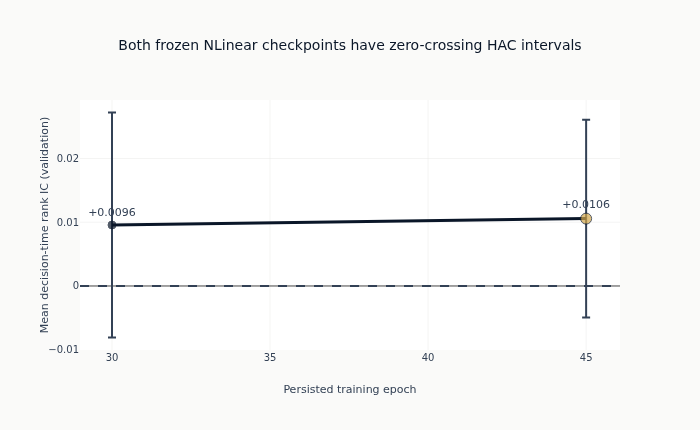

In [13]:
checkpoint_figure = go.Figure(
    go.Scatter(
        x=checkpoint_table["epoch"].to_list(),
        y=checkpoint_table["pooled_daily_ic"].to_list(),
        mode="markers+lines+text",
        line=dict(color=style.COLORS["blue"], width=3),
        marker=dict(
            size=[11 if selected else 8 for selected in checkpoint_table["selected"]],
            color=[
                style.COLORS["amber"] if selected else style.COLORS["blue"]
                for selected in checkpoint_table["selected"]
            ],
        ),
        text=[f"{value:+.4f}" for value in checkpoint_table["pooled_daily_ic"].to_list()],
        textposition="top center",
        error_y=dict(
            type="data",
            symmetric=False,
            array=(checkpoint_table["hac_ci_high"] - checkpoint_table["pooled_daily_ic"]).to_list(),
            arrayminus=(
                checkpoint_table["pooled_daily_ic"] - checkpoint_table["hac_ci_low"]
            ).to_list(),
            color=style.COLORS["neutral"],
        ),
        name="NLinear",
    )
)
checkpoint_figure.add_hline(y=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
checkpoint_figure.update_layout(
    template="ml4t",
    title="Both frozen NLinear checkpoints have zero-crossing HAC intervals",
    xaxis_title="Persisted training epoch",
    yaxis_title="Mean decision-time rank IC (validation)",
    height=430,
    showlegend=False,
)
checkpoint_figure.show()

## 4. Compare Frozen Model Families

The comparison reconstructs each physical model result without fitting. The
bars show point estimates; the paired NLinear-TCN interval below addresses the
close sequence-model comparison directly.

In [14]:
baseline_rows = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID]).select(
    "family", "ic_mean"
)
baseline_values = {
    "Ridge": float(baseline_rows.filter(pl.col("family") == "linear")["ic_mean"].item()),
    "GBM": float(baseline_rows.filter(pl.col("family") == "gbm")["ic_mean"].item()),
}

tcn_configs = [
    config
    for config in load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
    if config["params"].get("architecture") == "tcn"
]
for config in tcn_configs:
    config["n_epochs"] = N_EPOCHS
    config["batch_size"] = BATCH_SIZE
    config["params"]["lookback"] = LOOKBACK
tcn_result = run_dl_cv(
    dataset_pd,
    splits,
    feature_names=feature_names,
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    configs=tcn_configs,
    n_features=len(feature_names),
    device=DEVICE,
    save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
    register=True,
    force_retrain=False,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
    notebook="09_dl_tcn",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)

  SKIP tcn                        (complete (hash=41ccb0845202), split=validation)
All configs already registered - rebuilding result from frozen registry.


TabM is reconstructed separately because it uses the tabular runner, then all
frozen point estimates are assembled under one comparison schema.

In [15]:
tabm_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "tabular_dl")
for config in tabm_configs:
    config["n_epochs"] = 100
    config["batch_size"] = 4096
tabm_result = run_tabm_cv(
    pd.DataFrame(),
    splits,
    configs=tabm_configs,
    n_features=len(feature_names),
    feature_names=[],
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    device="cpu",
    save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
    register=True,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
)
if frozen_mode and _file_md5(registry_path) != registry_before:
    raise RuntimeError("Frozen baseline reconstruction modified registry.db")

baseline_values["TabM"] = float(tabm_result["best_ic"])
baseline_values["TCN"] = float(tcn_result["best_ic"])
baseline_values["NLinear"] = best_ic

comparison = pl.DataFrame(
    {"model": list(baseline_values), "pooled_daily_ic": list(baseline_values.values())}
).sort("pooled_daily_ic")

  SKIP tabm_s                     (complete (hash=0fd83d9ab0d4), split=validation)
  SKIP tabm_m                     (complete (hash=a584d604296b), split=validation)
  SKIP tabm_l                     (complete (hash=ff2a113a3bc9), split=validation)
All configs already registered - rebuilding result from frozen registry.


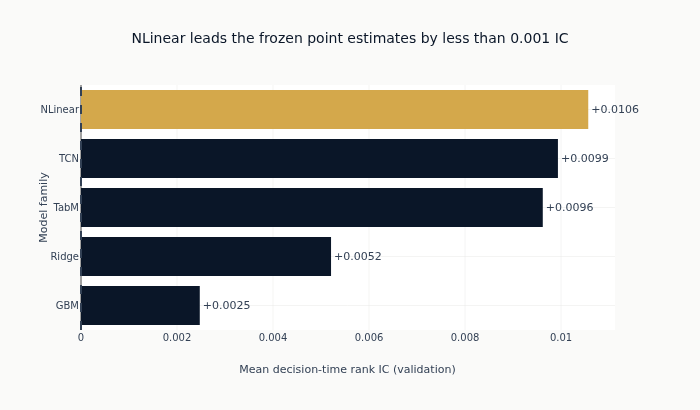

In [16]:
comparison_figure = go.Figure(
    go.Bar(
        x=comparison["pooled_daily_ic"].to_list(),
        y=comparison["model"].to_list(),
        orientation="h",
        marker_color=[
            style.COLORS["amber"] if model == "NLinear" else style.COLORS["blue"]
            for model in comparison["model"]
        ],
        text=[f"{value:+.4f}" for value in comparison["pooled_daily_ic"]],
        textposition="outside",
        cliponaxis=False,
    )
)
comparison_figure.add_vline(x=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
comparison_figure.update_layout(
    template="ml4t",
    title="NLinear leads the frozen point estimates by less than 0.001 IC",
    xaxis_title="Mean decision-time rank IC (validation)",
    yaxis_title="Model family",
    height=410,
    margin=dict(l=80, r=85, t=85),
    showlegend=False,
)
comparison_figure.show()

The paired comparison uses the daily rank-IC difference on the 2,064 shared
dates. This is the correct unit for testing whether one model ranks the same
cross-sections better than the other.

In [17]:
def _daily_ic(frame, name):
    return cross_sectional_ic_series(
        frame,
        frame,
        pred_col="y_score",
        ret_col="y_true",
        date_col=date_col,
        entity_col=entity_col,
        method="spearman",
        min_obs=5,
    ).select(date_col, pl.col("ic").alias(name))

In [18]:
nlinear_daily = _daily_ic(predictions, "nlinear_ic")
tcn_daily = _daily_ic(tcn_result["predictions"], "tcn_ic")
paired_daily = (
    nlinear_daily.join(tcn_daily, on=date_col, how="inner", validate="1:1")
    .with_columns((pl.col("nlinear_ic") - pl.col("tcn_ic")).alias("ic"))
    .sort(date_col)
)
paired_uncertainty = compute_ic_uncertainty(paired_daily.select("ic"), horizon=1, n_boot=1000)

print(f"Selected: {best_name} at epoch {best_epoch} ({vintage})")
print(f"Pooled daily IC: {best_ic:+.4f} across {int(headline['ic_n_days']):,} dates")
print(
    f"HAC 95% CI: [{headline['ic_ci_lo']:+.4f}, {headline['ic_ci_hi']:+.4f}]  "
    f"t={headline['ic_t_hac']:.2f}  p={headline['ic_p_hac']:.3f}  "
    f"lag={int(headline['ic_hac_lag'])}"
)
print(
    f"NLinear - TCN: {paired_uncertainty['mean_ic']:+.4f}  "
    f"HAC 95% CI [{paired_uncertainty['ci_hac_lower']:+.4f}, "
    f"{paired_uncertainty['ci_hac_upper']:+.4f}]  "
    f"p={paired_uncertainty['p_hac']:.3f}"
)
fold_metrics.select("fold", "ic")

Selected: nlinear at epoch 45 (v3.0 frozen)
Pooled daily IC: +0.0106 across 2,064 dates
HAC 95% CI: [-0.0049, +0.0261]  t=1.34  p=0.181  lag=7
NLinear - TCN: +0.0006  HAC 95% CI [-0.0197, +0.0210]  p=0.951


fold,ic
i64,f64
0,0.021466
1,0.017998
2,-0.016774
3,0.023017
4,0.01256
5,0.006132
6,0.004768
7,0.015364


## 5. Result Disposition

The default execution is read-only. It reconstructs the v3.0 NLinear result
for reader inspection while testing current fold and sequence construction.
A clean current-contract CPU retrain is a separate v3.1 measurement task.

In [19]:
ridge_delta = best_ic - baseline_values["Ridge"]
tcn_delta = best_ic - baseline_values["TCN"]
tabm_delta = best_ic - baseline_values["TabM"]
positive_folds = fold_metrics.filter(pl.col("ic") > 0).height

print(f"Selected predictions: {predictions.height:,} rows")
print(f"Physical checkpoints: {checkpoint_table.height}")
print(f"Positive folds: {positive_folds}/{fold_metrics.height}")
print(f"Delta over Ridge: {ridge_delta:+.4f}")
print(f"Registry unchanged: {registry_before == _file_md5(registry_path)}")
print(
    "Current-contract retrain: queued for v3.1" if frozen_mode else "Current-contract run complete"
)

Selected predictions: 41,280 rows
Physical checkpoints: 2
Positive folds: 7/8
Delta over Ridge: +0.0054
Registry unchanged: True
Current-contract retrain: queued for v3.1


## 6. Key Takeaways

1. **The frozen NLinear estimate is small and unresolved.** Epoch 45 reaches
   pooled daily IC +0.0106, with HAC 95% CI [-0.0049, +0.0261], p=0.181,
   and positive IC in seven of eight folds.
2. **NLinear does not separate from TCN.** Its point estimate is only about
   +0.0006 higher, and the paired daily HAC interval crosses zero.
3. **The flat-feature comparison does not identify a normalization effect.**
   NLinear exceeds Ridge by about +0.0054, but the models consume different
   representations; the prior claim that Ridge failed because it lacked
   last-value normalization was not supported.
4. **The frozen book value remains aligned.** Chapter 13 reports FX NLinear at
   +0.011 after rounding. The notebook's prior +0.014 claim was stale.
5. **A current-contract rerun belongs in v3.1.** The frozen prediction rows
   predate the exact fold-aware sequence contract tested here.

**Next**: [`11_causal_dml`](11_causal_dml.ipynb) asks a different question:
whether carry exposure has a causal interpretation after confounder control.